# Experimento: Variações de Arquitetura do Modelo PMC 2 (Momentum)

Este notebook tem como objetivo analisar o comportamento e o desempenho da rede neural **Perceptron Multicamadas (PMC) com fator de Momentum (0.9)** sob diferentes variações de arquitetura (número de camadas ocultas e quantidade de neurônios).

Todas as variações compartilham a mesma divisão determinística de dados: **800 primeiras amostras para treino** e **200 seguintes para teste**.

In [1]:
# ==================================================================
# BLOCO 1: Carregamento e Pré-processamento Padronizado dos Dados
# ==================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Leitura do dataset
df = pd.read_csv('car_price_dataset.csv')

# Mapeamento categórico para Fuel_Type
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Electric': 2, 'Hybrid': 3}
df['Fuel_Type'] = df['Fuel_Type'].map(fuel_mapping)

# Seleção das 6 features de entrada padronizadas
features = ['Year', 'Engine_Size', 'Fuel_Type', 'Mileage', 'Owner_Count', 'Doors']
X = df[features].values[:1000]
y = df['Price'].values[:1000].reshape(-1, 1)

# Normalização Z-Score pura (Numpy) para X
medias = np.mean(X, axis=0)
desvios = np.std(X, axis=0)
desvios[desvios == 0] = 1e-8
X_norm = (X - medias) / desvios

# Normalização Z-Score para o Preço (y)
media_y = np.mean(y)
desvio_y = np.std(y)
y_norm = (y - media_y) / desvio_y

# Divisão determinística de Treino (800) e Teste (200) sem embaralhamento
X_treino, X_teste = X_norm[:800], X_norm[800:1000]
y_treino, y_teste = y_norm[:800], y_norm[800:1000]
idx_teste = np.arange(800, 1000)

In [2]:
# ==================================================================
# BLOCO 2: Classe RedeNeuralNumpy com Suporte a Momentum
# ==================================================================
class RedeNeuralNumpy:
    def __init__(self, topologia, taxa_aprendizado=0.005, momentum=0.9):
        self.topologia = topologia
        self.lr = taxa_aprendizado
        self.momentum = momentum
        self.pesos = []
        self.vieses = []
        self.v_pesos = []
        self.v_vieses = []

        # Inicialização He para evitar desvanecimento de gradiente
        for i in range(len(topologia) - 1):
            W = np.random.randn(topologia[i], topologia[i+1]) * np.sqrt(2. / topologia[i])
            b = np.zeros((1, topologia[i+1]))
            self.pesos.append(W)
            self.vieses.append(b)
            self.v_pesos.append(np.zeros_like(W))
            self.v_vieses.append(np.zeros_like(b))

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _derivada_sigmoid(self, a):
        return a * (1.0 - a)

    def forward(self, X):
        ativacoes = [X]
        # Camadas ocultas com ativação Sigmoide
        for i in range(len(self.pesos) - 1):
            z = np.dot(ativacoes[-1], self.pesos[i]) + self.vieses[i]
            a = self._sigmoid(z)
            ativacoes.append(a)
        # Camada de saída Linear para predição numérica contínua
        z_saida = np.dot(ativacoes[-1], self.pesos[-1]) + self.vieses[-1]
        ativacoes.append(z_saida)
        return ativacoes

    def backward(self, ativacoes, y_verdadeiro):
        m = y_verdadeiro.shape[0]
        delta = (ativacoes[-1] - y_verdadeiro)

        grad_pesos = []
        grad_vieses = []

        # Gradientes da camada de saída
        grad_W = np.dot(ativacoes[-2].T, delta) / m
        grad_b = np.sum(delta, axis=0, keepdims=True) / m
        grad_pesos.append(grad_W)
        grad_vieses.append(grad_b)

        # Backpropagation nas camadas ocultas
        for i in range(len(self.pesos) - 2, -1, -1):
            delta = np.dot(delta, self.pesos[i+1].T) * self._derivada_sigmoid(ativacoes[i+1])
            grad_W = np.dot(ativacoes[i].T, delta) / m
            grad_b = np.sum(delta, axis=0, keepdims=True) / m
            grad_pesos.insert(0, grad_W)
            grad_vieses.insert(0, grad_b)

        # Atualização com Momentum
        for i in range(len(self.pesos)):
            self.v_pesos[i] = (self.momentum * self.v_pesos[i]) + (self.lr * grad_pesos[i])
            self.v_vieses[i] = (self.momentum * self.v_vieses[i]) + (self.lr * grad_vieses[i])
            self.pesos[i] -= self.v_pesos[i]
            self.vieses[i] -= self.v_vieses[i]

    def treinar(self, X, y, epocas):
        historico_mse = []
        for _ in range(epocas):
            ativacoes = self.forward(X)
            self.backward(ativacoes, y)
            mse = np.mean((ativacoes[-1] - y) ** 2)
            historico_mse.append(mse)
        return historico_mse

In [3]:
# ==================================================================
# BLOCO 3: Treinamento das Diferentes Topologias (Variações)
# ==================================================================
configuracoes = [
    {"nome": "PMC Momentum (Rasa)", "topologia": [6, 5, 1], "camadas": "1 camada", "neuronios": "5 neurônios"},
    {"nome": "PMC Momentum (Base - Original)", "topologia": [6, 15, 1], "camadas": "1 camada", "neuronios": "15 neurônios"},
    {"nome": "PMC Momentum (Média)", "topologia": [6, 16, 8, 1], "camadas": "2 camadas", "neuronios": "16 e 8 neurônios"},
    {"nome": "PMC Momentum (Profunda)", "topologia": [6, 32, 16, 8, 1], "camadas": "3 camadas", "neuronios": "32, 16 e 8 neurônios"},
    {"nome": "PMC Momentum (Muito Profunda)", "topologia": [6, 64, 32, 16, 1], "camadas": "3 camadas", "neuronios": "64, 32 e 16 neurônios"}
]

epocas = 1500
taxa_aprendizado = 0.005
resultados_gerais = []
historicos_perda = {}

print("Treinando variações do PMC 2 (Momentum) por 1500 épocas...")
for config in configuracoes:
    print(f"\nTreinando: {config['nome']} (Topologia: {config['topologia']})")
    np.random.seed(42)
    
    t0 = time.time()
    modelo = RedeNeuralNumpy(config['topologia'], taxa_aprendizado=taxa_aprendizado, momentum=0.9)
    historico = modelo.treinar(X_treino, y_treino, epocas)
    tempo_treino = time.time() - t0
    
    historicos_perda[config['nome']] = historico
    
    # Avaliação de métricas no conjunto de testes de 200 amostras
    y_teste_reais = y_teste * desvio_y + media_y
    pred = modelo.forward(X_teste)[-1]
    pred_reais = pred * desvio_y + media_y
    erros_reais = y_teste_reais - pred_reais
    
    eqm_teste_real = float(np.mean(erros_reais**2))
    mape = float(np.mean(np.abs(erros_reais / y_teste_reais)))
    acuracia = float(np.mean(np.abs(erros_reais / y_teste_reais) <= 0.10) * 100)
    precisao = float(max(0.0, (1.0 - mape) * 100))
    
    resultados_gerais.append({
        'Modelo': config['nome'],
        'Épocas': epocas,
        'Camadas Ocultas': config['camadas'],
        'Neurônios (Ocultos)': config['neuronios'],
        'Acurácia (%)': acuracia,
        'Precisão (%)': precisao,
        'EQM (Real)': eqm_teste_real,
        'Tempo de Treino (s)': tempo_treino,
        '_modelo_objeto': modelo
    })
    print(f"-> Concluído em {tempo_treino:.4f}s | Acurácia: {acuracia:.2f}% | Precisão: {precisao:.2f}%")

Treinando variações do PMC 2 (Momentum) por 1500 épocas...

Treinando: PMC Momentum (Rasa) (Topologia: [6, 5, 1])
-> Concluído em 0.2897s | Acurácia: 55.00% | Precisão: 89.27%

Treinando: PMC Momentum (Base - Original) (Topologia: [6, 15, 1])
-> Concluído em 0.6399s | Acurácia: 55.00% | Precisão: 89.44%

Treinando: PMC Momentum (Média) (Topologia: [6, 16, 8, 1])
-> Concluído em 0.7868s | Acurácia: 50.50% | Precisão: 88.84%

Treinando: PMC Momentum (Profunda) (Topologia: [6, 32, 16, 8, 1])
-> Concluído em 1.9476s | Acurácia: 49.50% | Precisão: 88.80%

Treinando: PMC Momentum (Muito Profunda) (Topologia: [6, 64, 32, 16, 1])
-> Concluído em 3.9689s | Acurácia: 50.50% | Precisão: 89.21%


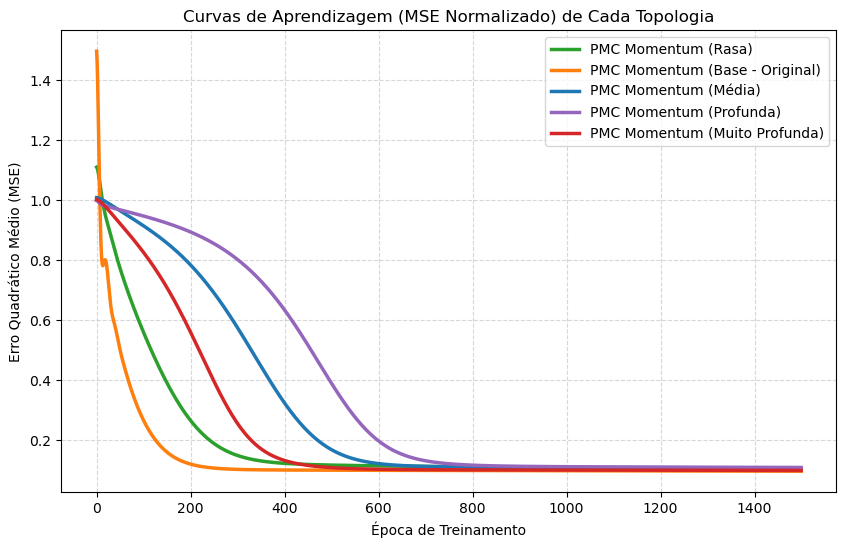

In [4]:
# ==================================================================
# BLOCO 4: Gráfico Combinado de Curvas de Aprendizado (Perda)
# ==================================================================
plt.figure(figsize=(10, 6))
cores = ['#2ca02c', '#ff7f0e', '#1f77b4', '#9467bd', '#d62728']
for idx, (nome, hist) in enumerate(historicos_perda.items()):
    plt.plot(hist, label=nome, color=cores[idx], linewidth=2.5)

plt.title('Curvas de Aprendizagem (MSE Normalizado) de Cada Topologia')
plt.xlabel('Época de Treinamento')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [5]:
# ==================================================================
# BLOCO 5: Tabela de Comparação (Leaderboard Geral)
# ==================================================================
df_comparativo = pd.DataFrame(resultados_gerais)
df_tabela = df_comparativo.drop(columns=['_modelo_objeto'])

# Ordenação: Maior acurácia e precisão de forma decrescente
df_tabela = df_tabela.sort_values(by=['Acurácia (%)', 'Precisão (%)'], ascending=[False, False])

# Formatação da visualização
df_formatado = df_tabela.copy()
df_formatado['Acurácia (%)'] = df_formatado['Acurácia (%)'].apply("{:.2f}%".format)
df_formatado['Precisão (%)'] = df_formatado['Precisão (%)'].apply("{:.2f}%".format)
df_formatado['EQM (Real)'] = df_formatado['EQM (Real)'].apply("R$ {:,.2f}".format)
df_formatado['Tempo de Treino (s)'] = df_formatado['Tempo de Treino (s)'].apply("{:.4f}s".format)

print("="*110)
print("             TABELA COMPARATIVA DE DESEMPENHO (LEADERBOARD DE VARIAÇÕES)")
print("="*110)
display(df_formatado)

             TABELA COMPARATIVA DE DESEMPENHO (LEADERBOARD DE VARIAÇÕES)


,Modelo,Épocas,Camadas Ocultas,Neurônios (Ocultos),Acurácia (%),Precisão (%),EQM (Real),Tempo de Treino (s)
1,PMC Momentum (Base - Original),1500,1 camada,15 neurônios,55.00%,89.44%,"R$ 967,109.11",0.6399s
0,PMC Momentum (Rasa),1500,1 camada,5 neurônios,55.00%,89.27%,"R$ 1,015,675.75",0.2897s
4,PMC Momentum (Muito Profunda),1500,3 camadas,"64, 32 e 16 neurônios",50.50%,89.21%,"R$ 1,022,546.21",3.9689s
2,PMC Momentum (Média),1500,2 camadas,16 e 8 neurônios,50.50%,88.84%,"R$ 1,104,771.69",0.7868s
3,PMC Momentum (Profunda),1500,3 camadas,"32, 16 e 8 neurônios",49.50%,88.80%,"R$ 1,107,274.33",1.9476s


        ESTATÍSTICAS DO DATASET E DISTRIBUIÇÃO DAS AMOSTRAS
Total de Amostras Carregadas: 1000 carros (Restrição das 1000 primeiras)
  - Conjunto de Treinamento:   800 carros (80.0% das amostras)
  - Conjunto de Teste Geral:   200 carros (20.0% das amostras)
  - Classificação Local:       10 carros (Predição detalhada)

             TABELA DE PREVISÕES LOCAIS: 10 CARROS DO CONJUNTO DE TESTE


,Linha CSV,Preço Real,PMC Momentum (Rasa),PMC Momentum (Base - Original),PMC Momentum (Média),PMC Momentum (Profunda),PMC Momentum (Muito Profunda)
0,800,"R$ 6,012.00","R$ 5,395.87","R$ 5,245.43","R$ 5,219.30","R$ 5,351.02","R$ 5,329.48"
1,801,"R$ 4,008.00","R$ 5,273.05","R$ 5,265.49","R$ 5,474.72","R$ 5,055.94","R$ 5,208.23"
2,802,"R$ 9,379.00","R$ 10,590.50","R$ 10,625.48","R$ 10,643.44","R$ 10,720.08","R$ 10,719.23"
3,803,"R$ 9,617.00","R$ 10,377.68","R$ 10,340.23","R$ 10,318.06","R$ 10,108.89","R$ 10,539.79"
4,804,"R$ 6,843.00","R$ 7,672.60","R$ 7,737.37","R$ 7,562.96","R$ 7,672.57","R$ 7,572.57"
5,805,"R$ 7,438.00","R$ 7,774.02","R$ 7,819.50","R$ 7,576.20","R$ 7,780.19","R$ 7,595.11"
6,806,"R$ 13,901.00","R$ 13,205.80","R$ 13,172.70","R$ 13,496.80","R$ 13,299.43","R$ 13,517.37"
7,807,"R$ 3,441.00","R$ 4,971.63","R$ 4,528.99","R$ 4,233.52","R$ 4,352.72","R$ 4,590.47"
8,808,"R$ 6,354.00","R$ 4,662.60","R$ 4,494.34","R$ 4,859.76","R$ 4,572.31","R$ 4,471.73"
9,809,"R$ 11,567.00","R$ 11,090.11","R$ 11,113.35","R$ 11,260.80","R$ 11,157.63","R$ 10,924.82"


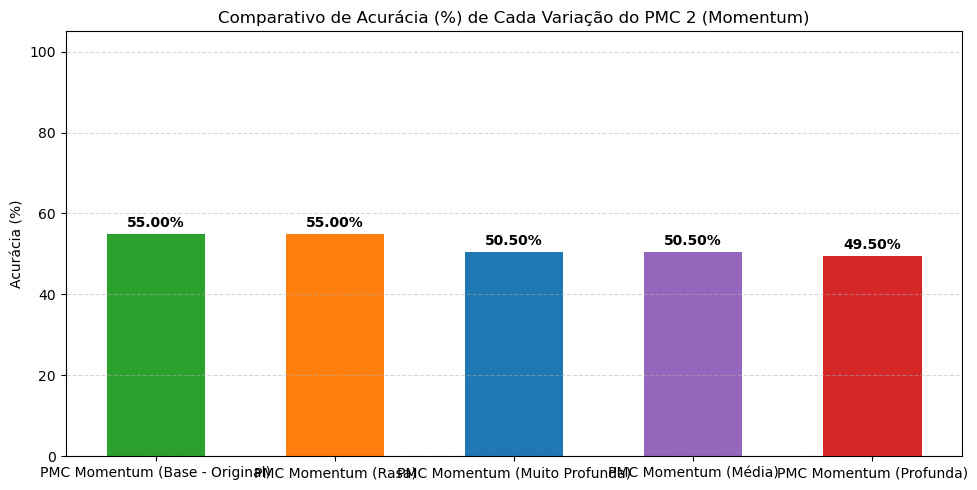

In [6]:
# ==================================================================
# BLOCO 6: Dashboard de Distribuição dos Dados e Predições Locais
# ==================================================================
total_dados = 1000
dados_treino = 800
dados_teste = 200
dados_classificacao_local = 10

print("="*75)
print("        ESTATÍSTICAS DO DATASET E DISTRIBUIÇÃO DAS AMOSTRAS")
print("="*75)
print(f"Total de Amostras Carregadas: {total_dados} carros (Restrição das 1000 primeiras)")
print(f"  - Conjunto de Treinamento:   {dados_treino} carros (80.0% das amostras)")
print(f"  - Conjunto de Teste Geral:   {dados_teste} carros (20.0% das amostras)")
print(f"  - Classificação Local:       {dados_classificacao_local} carros (Predição detalhada)")
print("="*75)

# Predições Locais para os 10 primeiros carros inéditos
resultados_locais = []
for i in range(dados_classificacao_local):
    linha_original = idx_teste[i]
    preco_real = float(y_teste_reais[i][0])
    
    row_dict = {
        "Linha CSV": linha_original,
        "Preço Real": preco_real
    }
    
    for res in resultados_gerais:
        modelo_obj = res['_modelo_objeto']
        carro_x = X_teste[i].reshape(1, -1)
        prev_norm = modelo_obj.forward(carro_x)[-1][0][0]
        prev_real = float(prev_norm * desvio_y + media_y)
        row_dict[res['Modelo']] = prev_real
        
    resultados_locais.append(row_dict)

df_previsoes_local = pd.DataFrame(resultados_locais)

# Formatação monetária dos preços
for col in df_previsoes_local.columns:
    if col != "Linha CSV":
        df_previsoes_local[col] = df_previsoes_local[col].apply("R$ {:,.2f}".format)

print("\n" + "="*110)
print("             TABELA DE PREVISÕES LOCAIS: 10 CARROS DO CONJUNTO DE TESTE")
print("="*110)
display(df_previsoes_local)

# Gráfico de Comparação de Acurácia das Variações
plt.figure(figsize=(10, 5))
cores_barras = ['#2ca02c', '#ff7f0e', '#1f77b4', '#9467bd', '#d62728']
bars = plt.bar(df_tabela['Modelo'], df_tabela['Acurácia (%)'], color=cores_barras, width=0.55)

plt.title('Comparativo de Acurácia (%) de Cada Variação do PMC 2 (Momentum)')
plt.ylabel('Acurácia (%)')
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adicionar rótulos nas barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()